# Taller 4: Detección de contornos

## 1. Filtros lineales de detección de contornos

### 1.1 Cree una nueva sección en su notebook.

### 1.2 Cargue la imagen objects.png y visualícela.  Transforme la imagen a Int32 conservando los mismos niveles de gris originales (0 y 255).

In [15]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

from skimage.filters import sobel_h, sobel_v, sobel
from skimage.filters import prewitt_h, prewitt_v, prewitt

In [3]:
# leer ruta de imagenes y sus contenidos
images_path = "images/"
os.listdir(images_path)

['OBJECTS.png']

Minimo: 7
Maximo: 188
Tipo de dato: int32


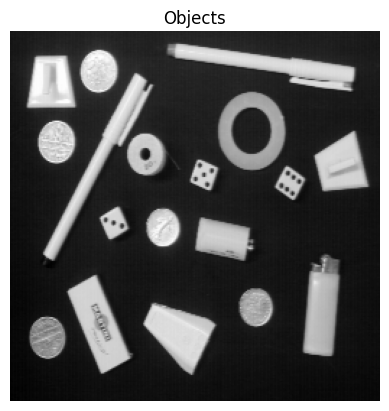

In [7]:
# leer imagen objects y pasar a int32
objects_image = cv2.imread(os.path.join(images_path, "OBJECTS.png"), cv2.IMREAD_GRAYSCALE).astype(np.int32)

# verificar que conserve los niveles de gris
print("Minimo:", np.min(objects_image))
print("Maximo:", np.max(objects_image))
print("Tipo de dato:", objects_image.dtype)

plt.imshow(objects_image, cmap="gray")
plt.title("Objects")
plt.axis("off")
plt.show()

### 1.3 Aplique un filtro de Sobel horizontal sobre la imagen (que corresponde al cálculo del gradiente de la imagen en la dirección X ). Visualice los resultados.

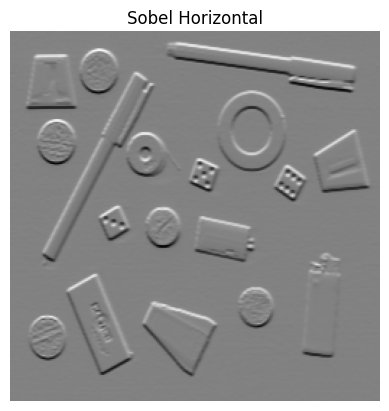

In [8]:
#Aplica el filtro Sobel horizontal
img_sh = sobel_h(objects_image)

#Visualiza el resultado
plt.imshow(img_sh, cmap="gray")
plt.title("Sobel Horizontal")
plt.axis("off")
plt.show()

### 1.4 Aplique un filtro de Sobel vertical sobre la imagen (que corresponde al cálculo del gradiente de la imagen en la dirección Y ). Visualice los resultados.

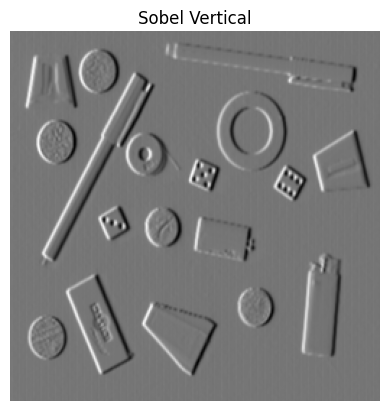

In [9]:
# aplicar el filtro Sobel vertical
img_sv = sobel_v(objects_image)

# visualizar el resultado
plt.imshow(img_sv, cmap="gray")
plt.title("Sobel Vertical")
plt.axis("off")
plt.show()

### 1.5 Calcule la norma (magnitud) del gradiente de acuerdo con la definición a partir de las dos imágenes resultantes anteriores. Visualice los resultados.

La magnitud del gradiente se puede calcular utilizando la fórmula:
$$\text{Magnitud} = \sqrt{(G_x)^2 + (G_y)^2}$$
donde $(G_x)$ es el resultado del filtro de Sobel horizontal y $(G_y)$ es el resultado del filtro de Sobel vertical. Visualice la imagen resultante utilizando una escala de grises para resaltar los bordes detectados.

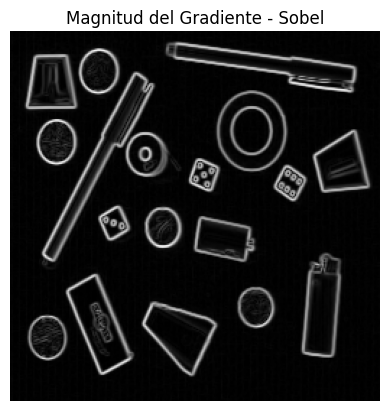

In [21]:
def calculate_gradient_magnitude(Gx, Gy):
    return np.sqrt(Gx**2 + Gy**2)

magnitud_sobel = calculate_gradient_magnitude(img_sh, img_sv)

# Visualizar la magnitud del gradiente
plt.imshow(magnitud_sobel, cmap="gray")
plt.title("Magnitud del Gradiente - Sobel")
plt.axis("off")
plt.show()

### 1.6 Describa cualitativamente cada una de estas tres imágenes: imagen del gradiente en X, imagen del gradiente en Y e imagen de la norma del gradiente.

### 1.7 Aplique un filtro de Sobel sobre la imagen y visualice los resultados. Compare la imagen con la obtenido en el punto anterior.

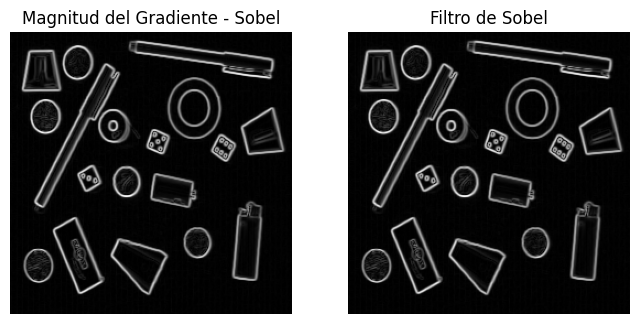

In [23]:
sobel_img = sobel(objects_image)

# Visualizar la imagen resultante del filtro de Sobel
plt.figure(figsize=(8, 6))
plt.subplot(1, 2, 1)
plt.imshow(magnitud_sobel, cmap="gray")
plt.title("Magnitud del Gradiente - Sobel")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(sobel_img, cmap="gray")
plt.title("Filtro de Sobel")
plt.axis("off")

plt.show()

### 1.8 Aplique un filtro de Prewitt horizontal sobre la imagen (que corresponde al cálculo del gradiente de la imagen en la dirección X ). Visualice los resultados.

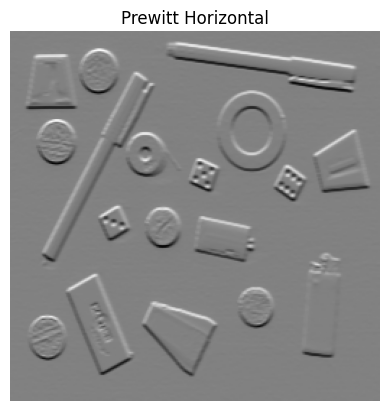

In [16]:
# prewitt horizontal
img_ph = prewitt_h(objects_image)

# visualizar el resultado
plt.imshow(img_ph, cmap="gray")
plt.title("Prewitt Horizontal")
plt.axis("off")
plt.show()

### 1.9 Aplique un filtro de Prewitt vertical sobre la imagen (que corresponde al cálculo del gradiente de la imagen en la dirección X ). Visualice los resultados.

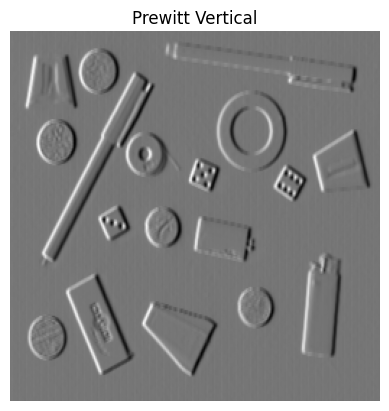

In [17]:
# prewitt vertical
img_pv = prewitt_v(objects_image)

# visualizar el resultado
plt.imshow(img_pv, cmap="gray")
plt.title("Prewitt Vertical")
plt.axis("off")
plt.show()

### 1.10 Calcule la norma (magnitud) del gradiente de acuerdo con la definición a partir de las dos imágenes resultantes anteriores. Visualice los resultados.

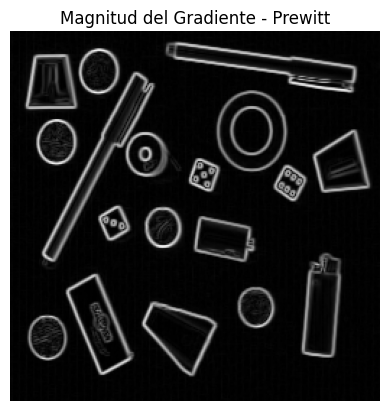

In [18]:
magnitud_prewitt = calculate_gradient_magnitude(img_ph, img_pv)

# Visualizar la magnitud del gradiente de Prewitt
plt.imshow(magnitud_prewitt, cmap="gray")
plt.title("Magnitud del Gradiente - Prewitt")
plt.axis("off")
plt.show()

### 1.11 Describa cualitativamente cada una de estas tres imágenes: imagen del gradiente en X, imagen del gradiente en Y e imagen de la norma del gradiente.

### 1.12 Aplique un filtro de Prewitt sobre la imagen y visualice los resultados. Compare la imagen con la obtenido en el punto anterior.

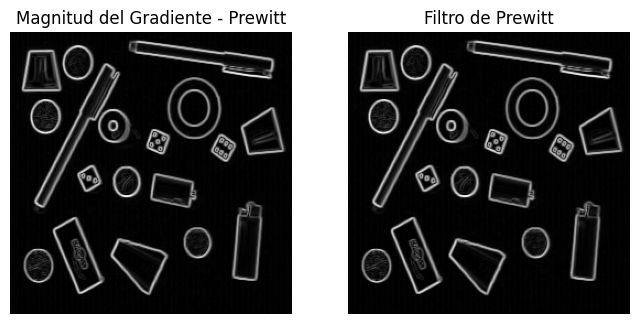

In [20]:
# filtro de Prewitt
prewitt_img = prewitt(objects_image)

# visualizar
plt.figure(figsize=(8, 6))
plt.subplot(1, 2, 1)
plt.imshow(magnitud_prewitt, cmap="gray")
plt.title("Magnitud del Gradiente - Prewitt")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(prewitt_img, cmap="gray")
plt.title("Filtro de Prewitt")
plt.axis("off")
plt.show()

### 1.13 Sustraiga a la imagen de la norma de Prewitt, la imagen de la norma del gradiente calculada con el operador de Sobel.

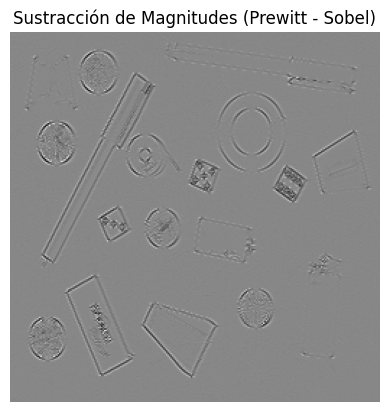

In [24]:
# aplicar la sustracción
subtraction = cv2.subtract(magnitud_prewitt, magnitud_sobel)

# visualizar el resultado
plt.imshow(subtraction, cmap="gray")
plt.title("Sustracción de Magnitudes (Prewitt - Sobel)")
plt.axis("off")
plt.show()

### 1.14 ¿Qué diferencia visual hay entre el operador de Sobel y el de Prewitt?

### 1.15 Para explicar esta diferencia, calcule numéricamente las respuestas del cálculo del gradiente en x, en y y de la norma del gradiente de cada uno de los dos filtros en los siguientes casos:

In [ ]:
# crear las matrices dadas
frontera_hor_blanco_negro = np.array([[0, 0, 0],
                                    [0, 0, 0],
                                    [255, 255, 255]])

frontera_ver_blanco_negro = np.array([[0, 0, 255],
                                    [0, 0, 255],
                                    [0, 0, 255]])

frontera_oblicua_blanco_negro = np.array([[0, 0, 255],
                                          [0, 255, 255],
                                          [255, 255, 255]])

mascara_alejada_frontera_oblicua = np.array([[0, 0, 0, 0],
                                             [0, ],
                                             [],
                                             []])